In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [4]:
df=pd.read_csv("/content/heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [5]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [7]:
df.groupby('RestingECG')['HeartDisease'].value_counts()

RestingECG  HeartDisease
LVH         1               106
            0                82
Normal      1               285
            0               267
ST          1               117
            0                61
Name: count, dtype: int64

In [8]:
df.shape

(918, 12)

In [9]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [10]:
df.duplicated().sum()

np.int64(0)

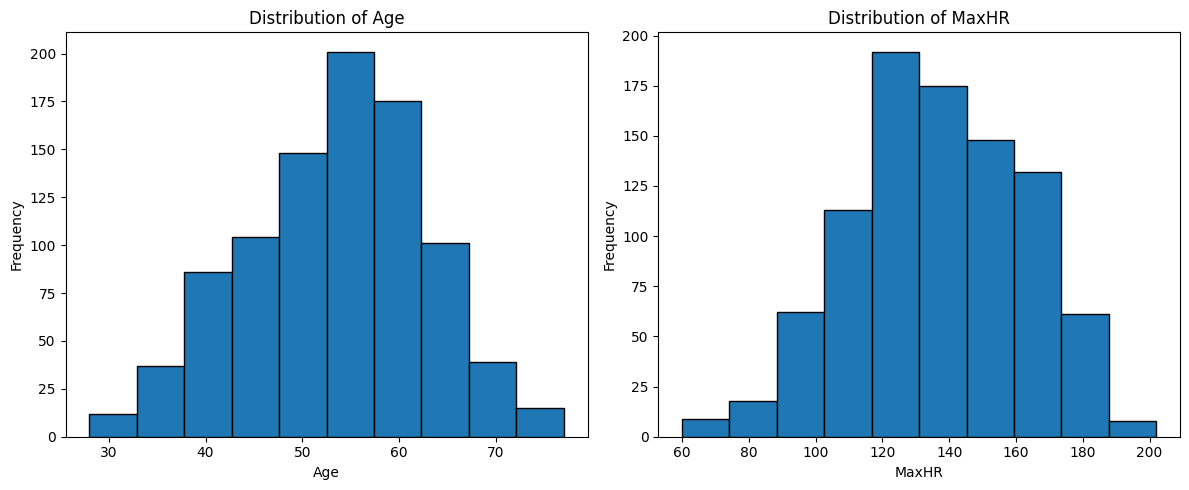

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["Age"], bins=10, edgecolor="black")
axes[0].set_title("Distribution of Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["MaxHR"], bins=10, edgecolor="black")
axes[1].set_title("Distribution of MaxHR")
axes[1].set_xlabel("MaxHR")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

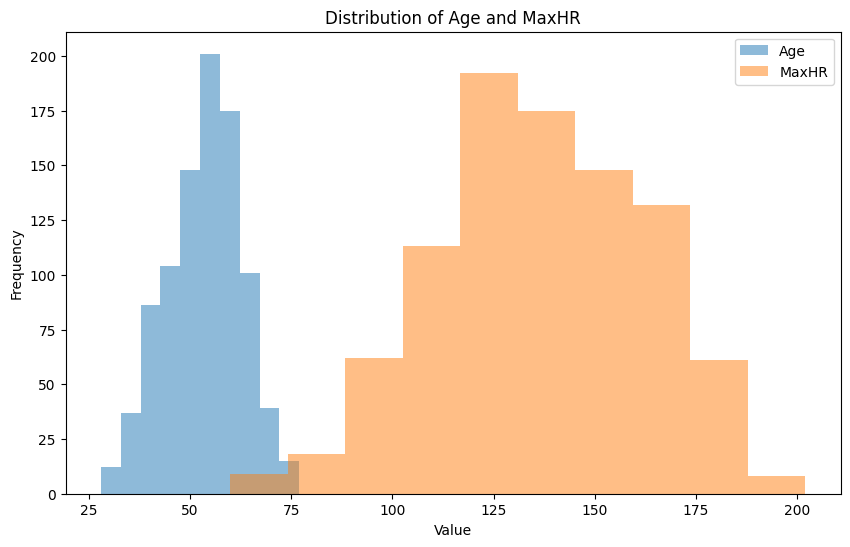

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df["Age"], bins=10, alpha=0.5, label="Age")
plt.hist(df["MaxHR"], bins=10, alpha=0.5, label="MaxHR")

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of Age and MaxHR")
plt.legend()
plt.show()

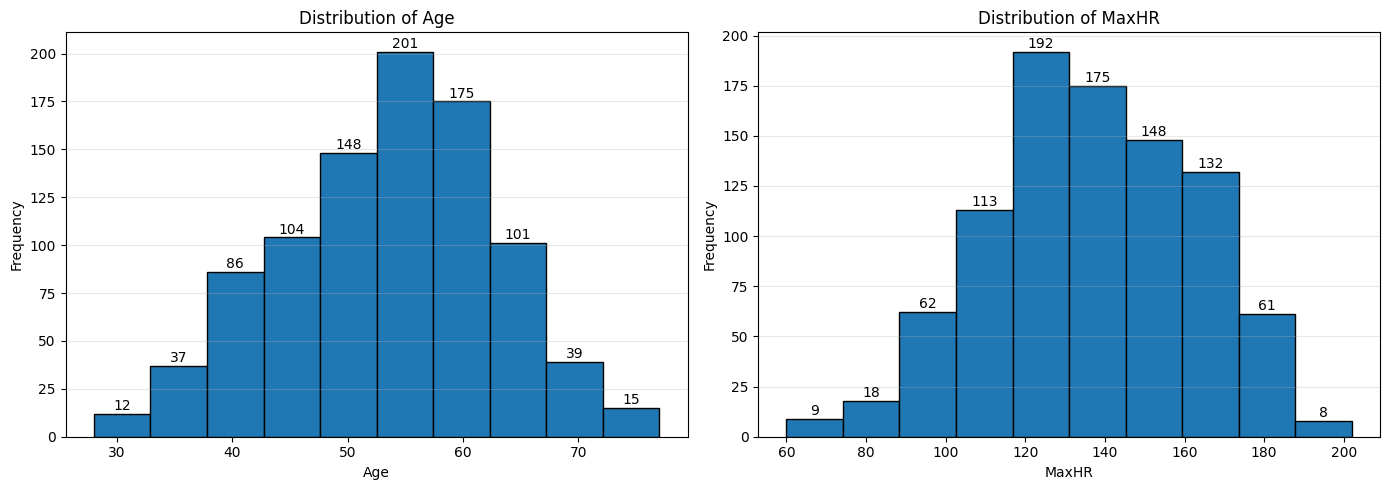

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------- Age Histogram --------
n, bins, patches = axes[0].hist(df["Age"], bins=10, edgecolor="black")

axes[0].set_title("Distribution of Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis="y", alpha=0.3)

# Frequency above bars
for i in range(len(n)):
    if n[i] > 0:
        axes[0].text(
            (bins[i] + bins[i+1]) / 2,
            n[i] + 2,
            int(n[i]),
            ha="center"
        )

# -------- MaxHR Histogram --------
n, bins, patches = axes[1].hist(df["MaxHR"], bins=10, edgecolor="black")

axes[1].set_title("Distribution of MaxHR")
axes[1].set_xlabel("MaxHR")
axes[1].set_ylabel("Frequency")
axes[1].grid(axis="y", alpha=0.3)

# Frequency above bars
for i in range(len(n)):
    if n[i] > 0:
        axes[1].text(
            (bins[i] + bins[i+1]) / 2,
            n[i] + 2,
            int(n[i]),
            ha="center"
        )

plt.tight_layout()
plt.show()

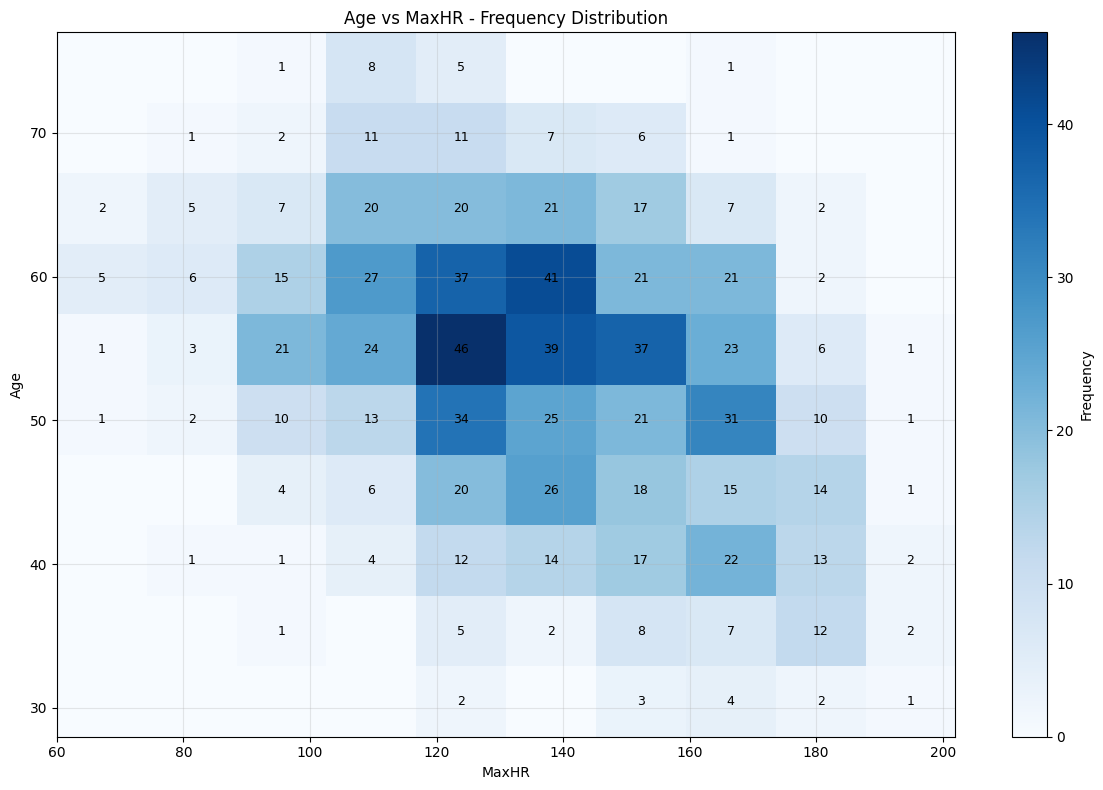

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# 2D histogram
hist = plt.hist2d(
    df["MaxHR"],
    df["Age"],
    bins=[10, 10],
    cmap="Blues"
)

# Add color bar showing frequency
cbar = plt.colorbar(hist[3])
cbar.set_label("Frequency")

# Get bin information
counts, xedges, yedges = hist[0], hist[1], hist[2]

# Add frequency numbers inside each box
for i in range(len(xedges) - 1):
    for j in range(len(yedges) - 1):
        if counts[i, j] > 0:
            x = (xedges[i] + xedges[i + 1]) / 2
            y = (yedges[j] + yedges[j + 1]) / 2

            plt.text(
                x, y,
                int(counts[i, j]),
                ha="center",
                va="center",
                fontsize=9
            )

plt.xlabel("MaxHR")
plt.ylabel("Age")
plt.title("Age vs MaxHR - Frequency Distribution")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show(

)

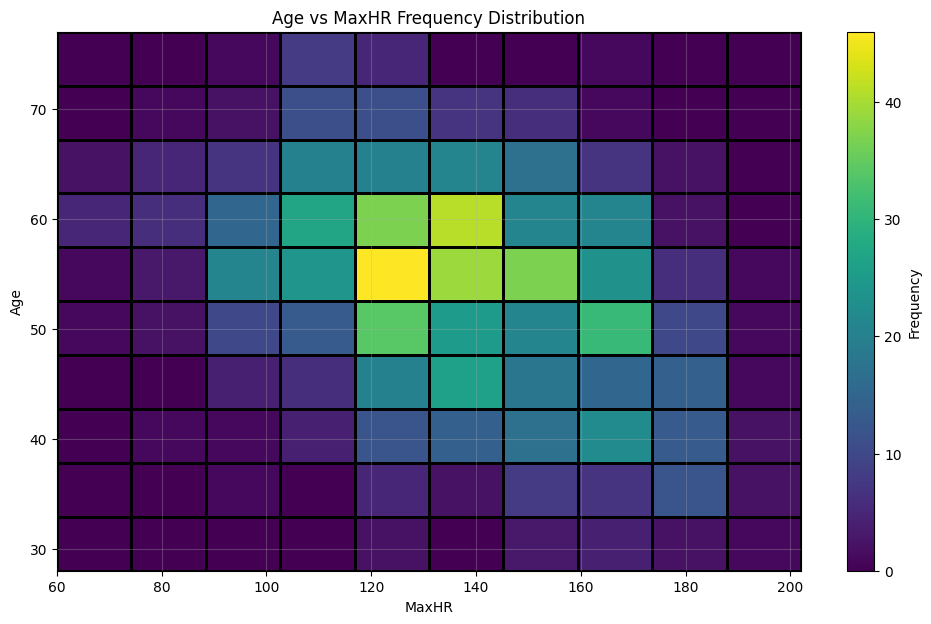

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.hist2d(
    df["MaxHR"],
    df["Age"],
    bins=10,
    edgecolor="black"
)

plt.xlabel("MaxHR")
plt.ylabel("Age")
plt.title("Age vs MaxHR Frequency Distribution")

plt.colorbar(label="Frequency")

plt.grid(True, alpha=0.3)

plt.show()

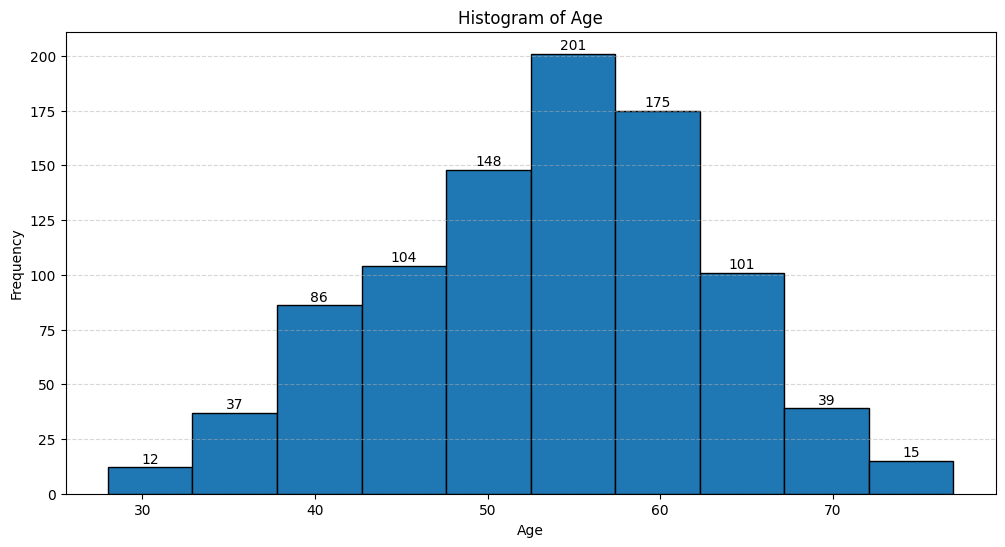

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

frequency, bins, patches = plt.hist(
    df["Age"],
    bins=10,
    edgecolor="black"
)

for i in range(len(frequency)):
    if frequency[i] > 0:
        plt.text(
            (bins[i] + bins[i+1]) / 2,
            frequency[i] + 2,
            int(frequency[i]),
            ha="center",
            fontsize=10
        )

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Histogram of Age")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

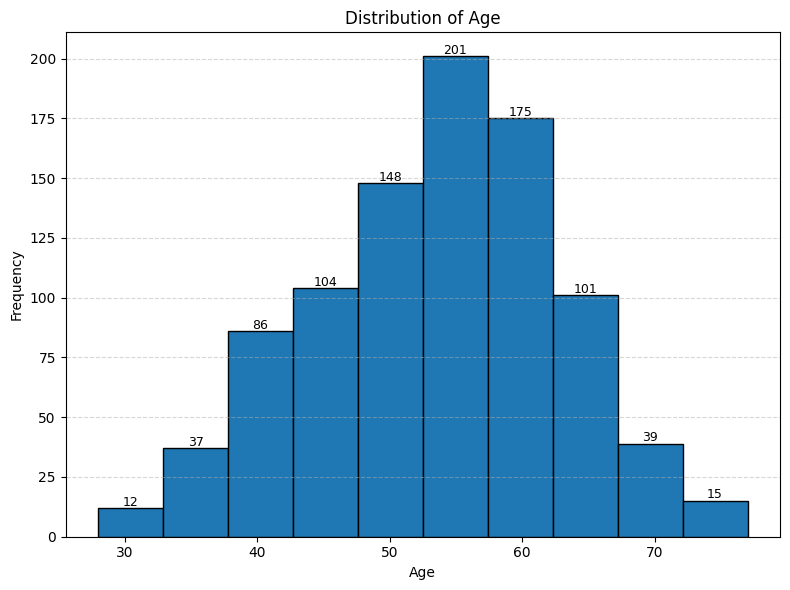

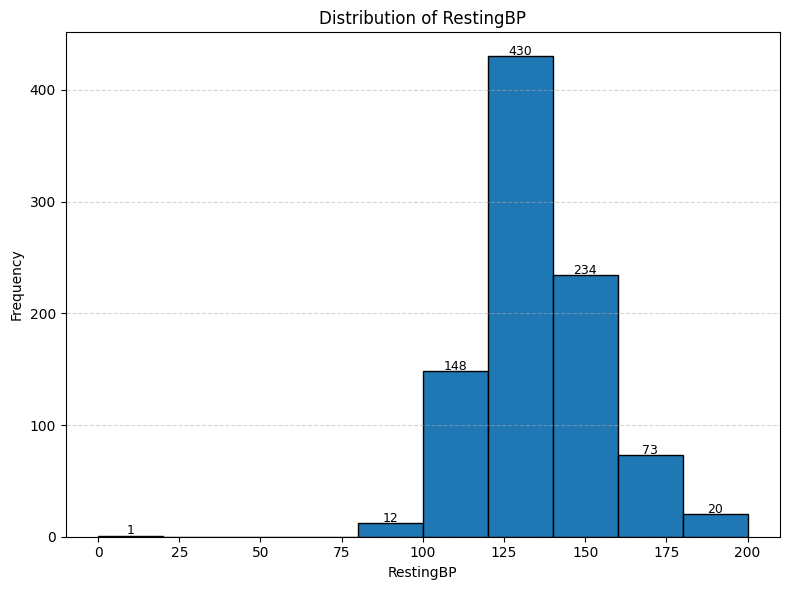

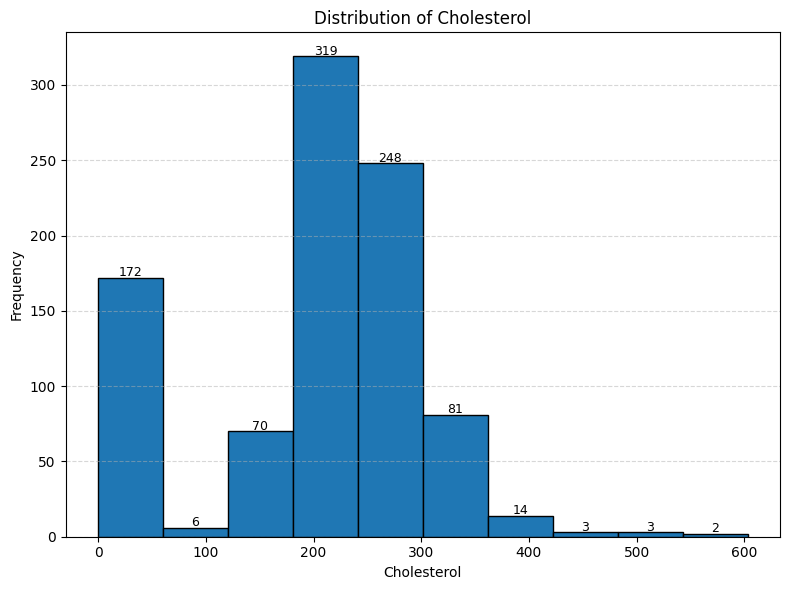

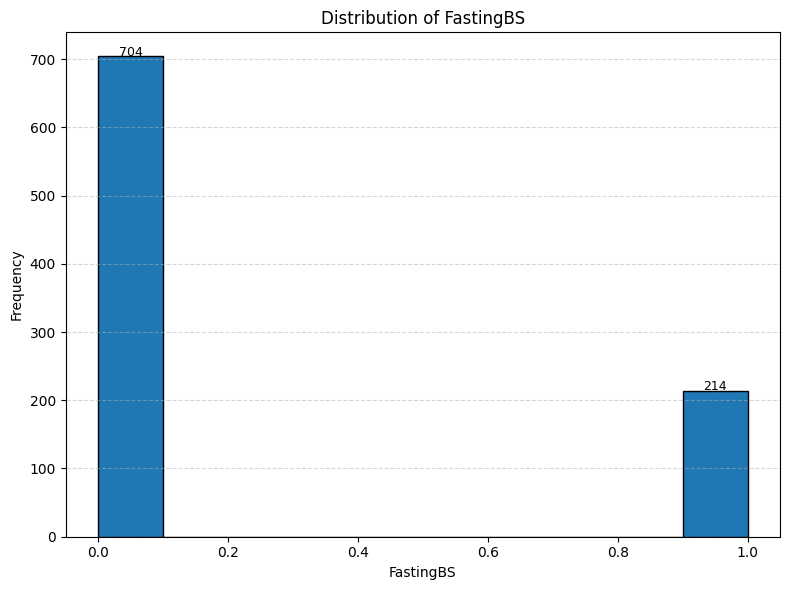

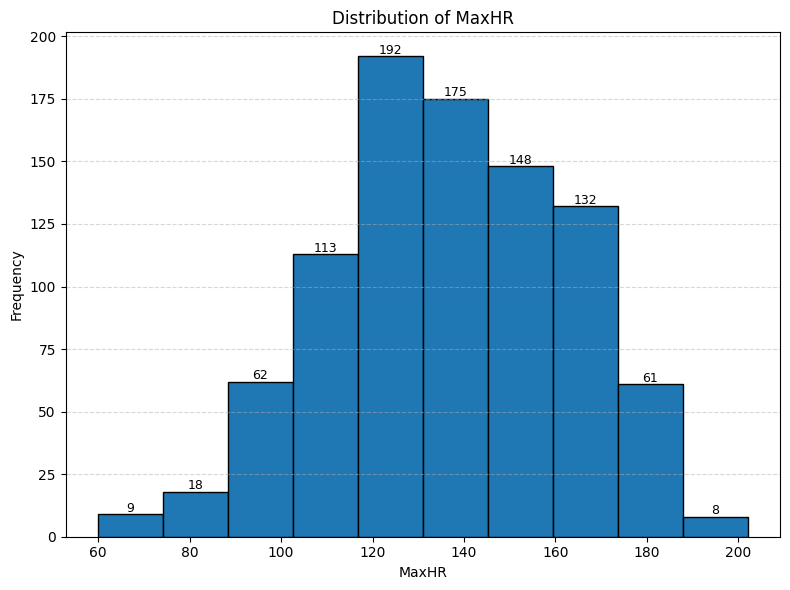

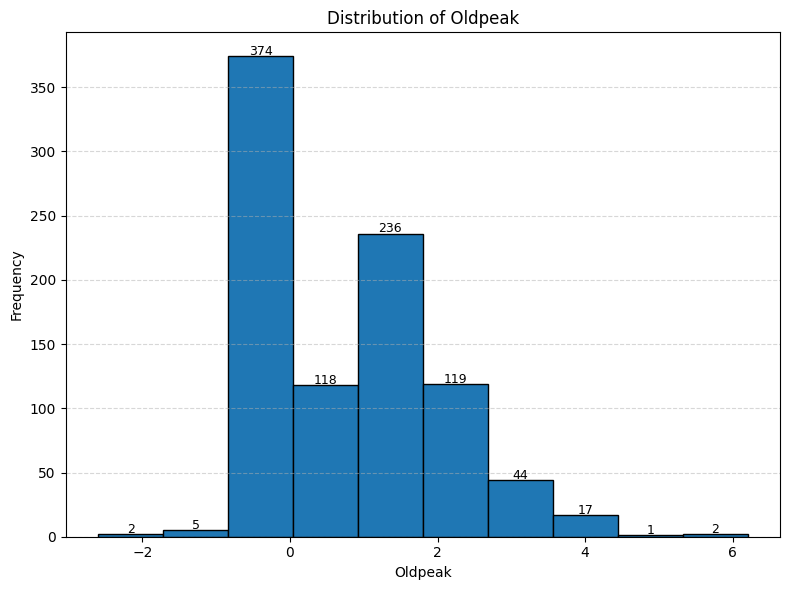

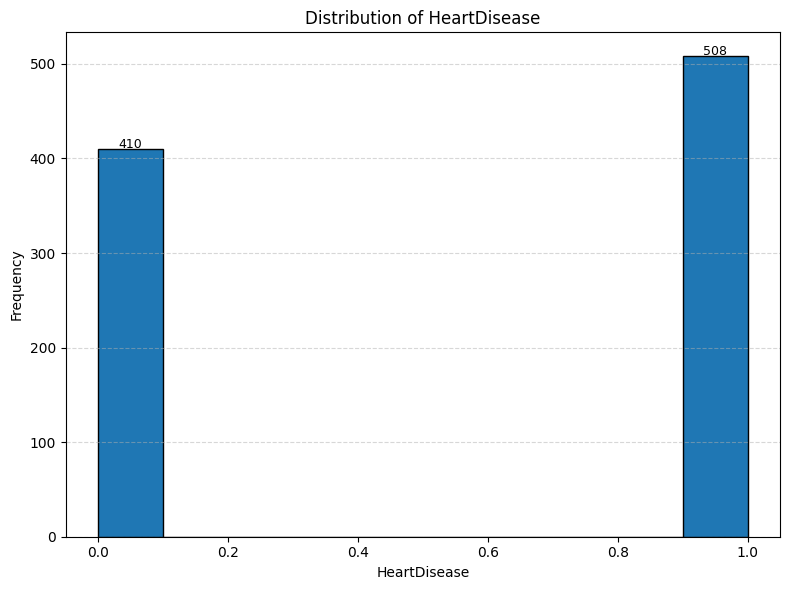

In [21]:
import matplotlib.pyplot as plt

# Select numerical columns
numerical_cols = df.select_dtypes(include="number").columns

# Create histogram for each numerical column
for col in numerical_cols:

    plt.figure(figsize=(8, 6))

    frequency, bins, patches = plt.hist(
        df[col].dropna(),
        bins=10,
        edgecolor="black"
    )

    # Add frequency numbers above bars
    for i in range(len(frequency)):
        if frequency[i] > 0:
            plt.text(
                (bins[i] + bins[i+1]) / 2,
                frequency[i] + 1,
                int(frequency[i]),
                ha="center",
                fontsize=9
            )

    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")

    # Grid
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

In [22]:
# Replace 0 with NaN
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['MaxHR'] = df['MaxHR'].replace(0, np.nan)

# Fill NaN with the column mean
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].mean())
df['MaxHR'] = df['MaxHR'].fillna(df['MaxHR'].mean())

In [23]:
print("Cholesterol zeros:", (df['Cholesterol'] == 0).sum())
print("MaxHR zeros:", (df['MaxHR'] == 0).sum())

Cholesterol zeros: 0
MaxHR zeros: 0


In [24]:
df['Cholesterol'] = df['Cholesterol'].replace(0, df['Cholesterol'].mean())
df['MaxHR'] = df['MaxHR'].replace(0, df['MaxHR'].mean())

In [25]:
print("Cholesterol zeros:", (df['Cholesterol'] == 0).sum())
print("MaxHR zeros:", (df['MaxHR'] == 0).sum())

Cholesterol zeros: 0
MaxHR zeros: 0


In [26]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236.0,0,LVH,174,N,0.0,Flat,1


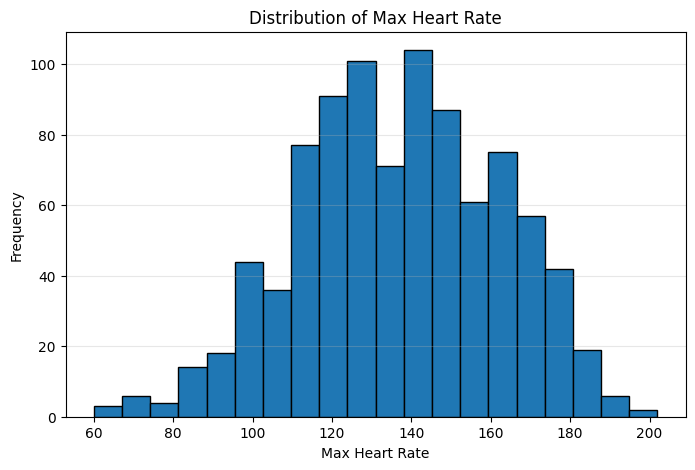

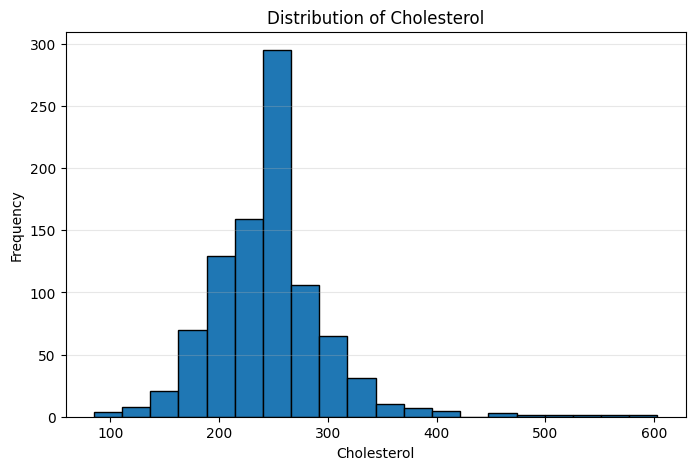

In [27]:
import matplotlib.pyplot as plt

# Histogram for MaxHR
plt.figure(figsize=(8, 5))
plt.hist(df['MaxHR'], bins=20, edgecolor='black')
plt.xlabel('Max Heart Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Max Heart Rate')
plt.grid(axis='y', alpha=0.3)
plt.show()


# Histogram for Cholesterol
plt.figure(figsize=(8, 5))
plt.hist(df['Cholesterol'], bins=20, edgecolor='black')
plt.xlabel('Cholesterol')
plt.ylabel('Frequency')
plt.title('Distribution of Cholesterol')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [28]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.7 MB/s eta 0:00:00


In [29]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Heart Disease Dataset Profiling Report")

profile.to_notebook_iframe()
profile.to_file("heart_disease_profile.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 49.81it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [31]:
# Correlation matrix for all numerical columns
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

                   Age  RestingBP  Cholesterol  FastingBS     MaxHR   Oldpeak  \
Age           1.000000   0.254399     0.053373   0.198039 -0.382045  0.258612   
RestingBP     0.254399   1.000000     0.080723   0.070193 -0.112135  0.164803   
Cholesterol   0.053373   0.080723     1.000000   0.043008 -0.017239  0.053029   
FastingBS     0.198039   0.070193     0.043008   1.000000 -0.131438  0.052698   
MaxHR        -0.382045  -0.112135    -0.017239  -0.131438  1.000000 -0.160691   
Oldpeak       0.258612   0.164803     0.053029   0.052698 -0.160691  1.000000   
HeartDisease  0.282039   0.107589     0.094071   0.267291 -0.400421  0.403951   

              HeartDisease  
Age               0.282039  
RestingBP         0.107589  
Cholesterol       0.094071  
FastingBS         0.267291  
MaxHR            -0.400421  
Oldpeak           0.403951  
HeartDisease      1.000000  


In [32]:
# Convert correlation matrix into pairs
corr_pairs = corr_matrix.unstack()

# Remove self-correlations (1.0)
corr_pairs = corr_pairs[corr_pairs != 1]

# Remove duplicate pairs
corr_pairs = corr_pairs.drop_duplicates()

# Sort by absolute correlation
highest_corr = corr_pairs.abs().sort_values(ascending=False)

print(highest_corr.head(10))


Oldpeak    HeartDisease    0.403951
MaxHR      HeartDisease    0.400421
Age        MaxHR           0.382045
           HeartDisease    0.282039
FastingBS  HeartDisease    0.267291
Age        Oldpeak         0.258612
           RestingBP       0.254399
           FastingBS       0.198039
RestingBP  Oldpeak         0.164803
MaxHR      Oldpeak         0.160691
dtype: float64


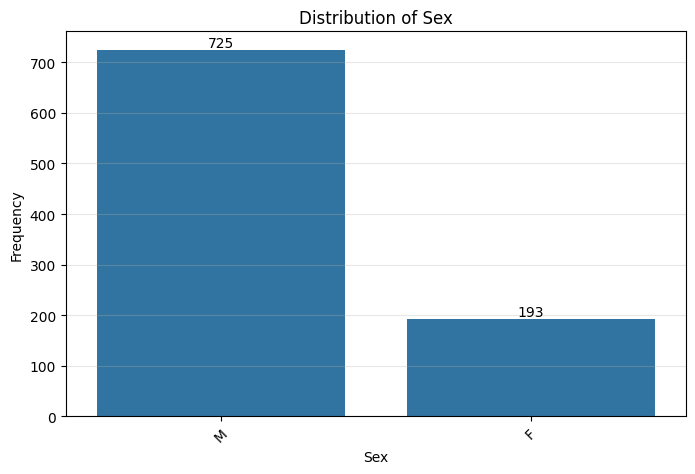

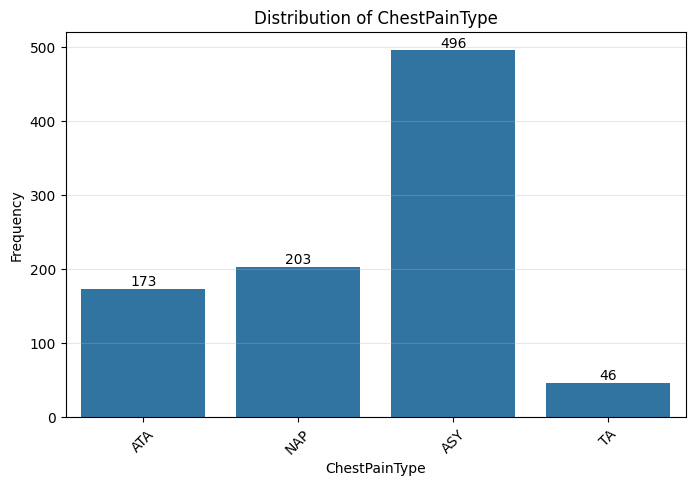

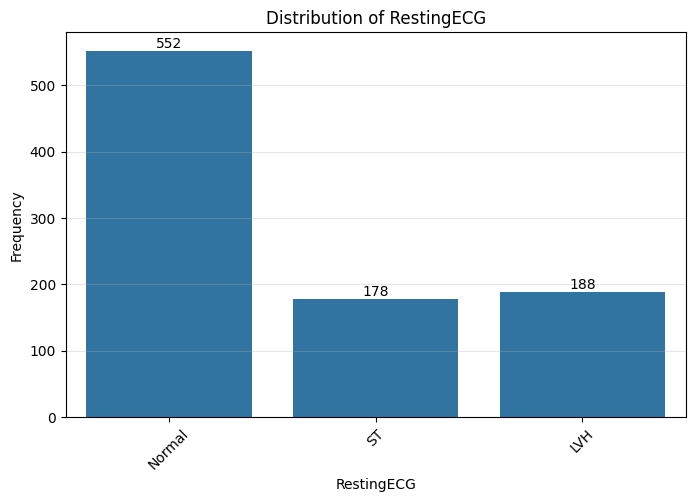

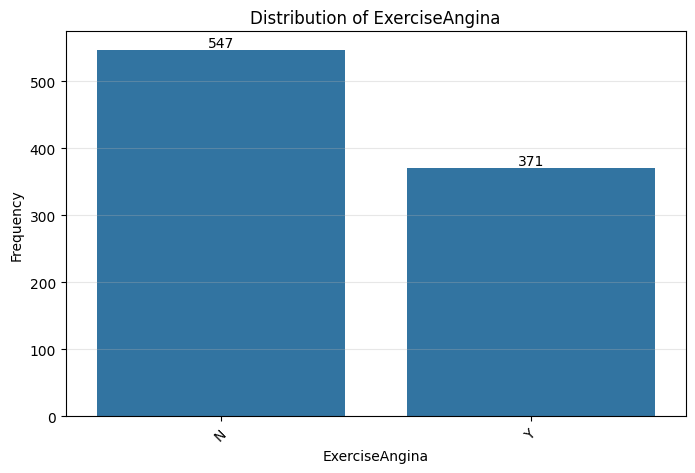

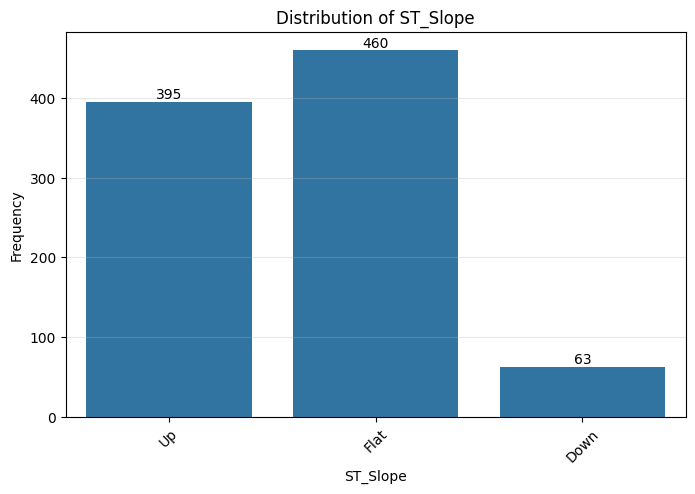

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(8, 5))

    ax = sns.countplot(data=df, x=col)

    # Add count numbers
    for container in ax.containers:
        ax.bar_label(container)

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

In [34]:
import pandas as pd
import numpy as np

# Select numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# Outlier analysis using IQR
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    outlier_summary.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Limit': lower_limit,
        'Upper Limit': upper_limit,
        'Outlier Count': len(outliers),
        'Outlier %': round((len(outliers) / len(df)) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

print(outlier_summary)

         Column     Q1     Q3   IQR  Lower Limit  Upper Limit  Outlier Count  \
0           Age   47.0   60.0  13.0        27.50        79.50              0   
1     RestingBP  120.0  140.0  20.0        90.00       170.00             28   
2   Cholesterol  214.0  267.0  53.0       134.50       346.50             41   
3     FastingBS    0.0    0.0   0.0         0.00         0.00            214   
4         MaxHR  120.0  156.0  36.0        66.00       210.00              2   
5       Oldpeak    0.0    1.5   1.5        -2.25         3.75             16   
6  HeartDisease    0.0    1.0   1.0        -1.50         2.50              0   

   Outlier %  
0       0.00  
1       3.05  
2       4.47  
3      23.31  
4       0.22  
5       1.74  
6       0.00  


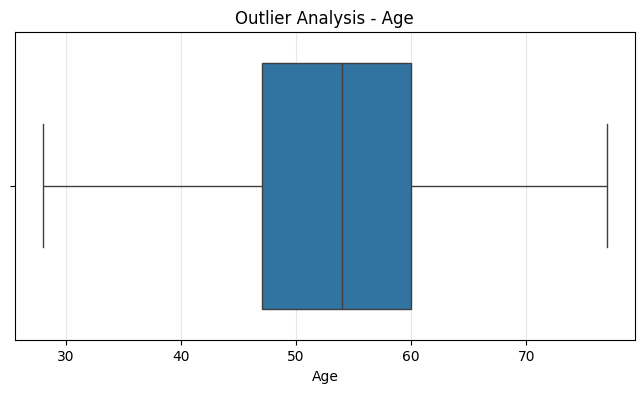

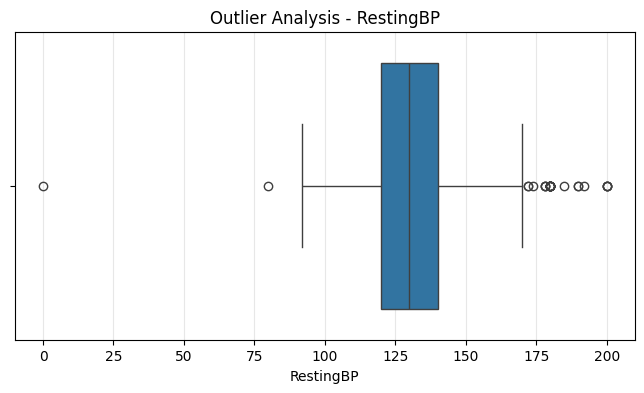

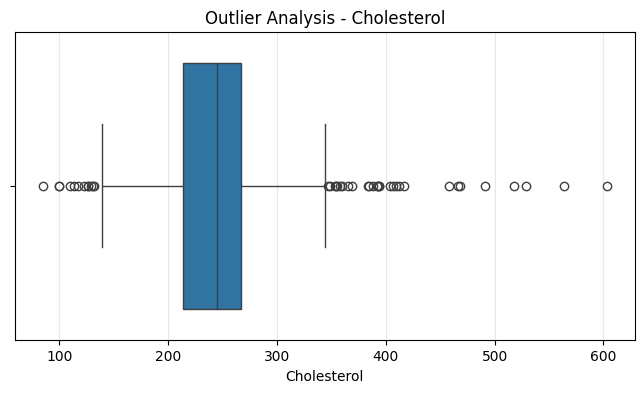

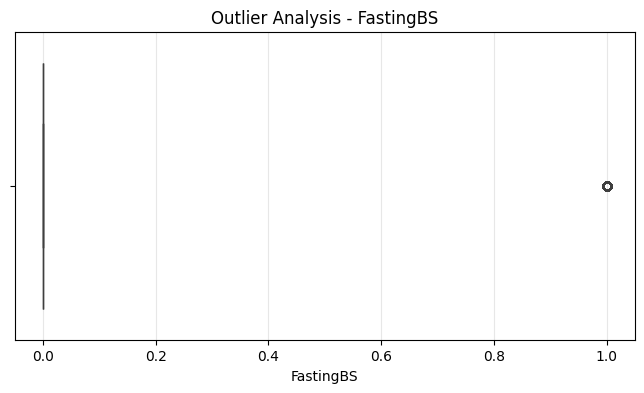

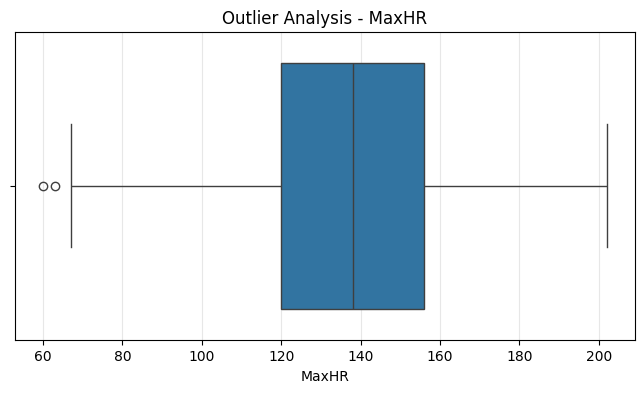

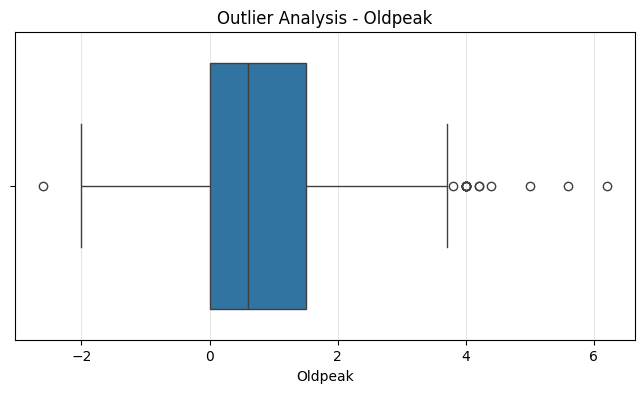

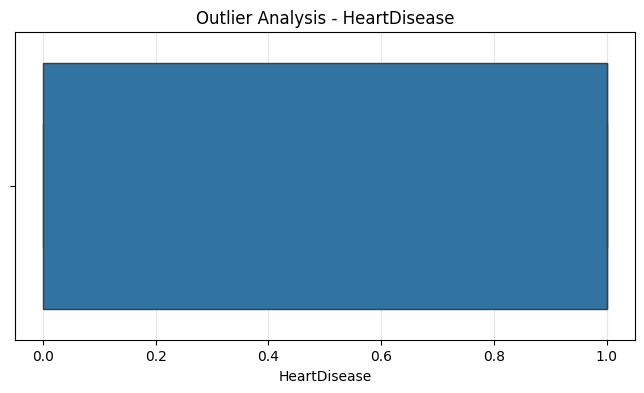

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Outlier Analysis - {col}')
    plt.xlabel(col)
    plt.grid(axis='x', alpha=0.3)
    plt.show()

In [36]:
from sklearn.preprocessing import StandardScaler

# Select numerical columns
num_cols = df.select_dtypes(include='number').columns

# Create scaler
scaler = StandardScaler()

# Apply standard scaling
df[num_cols] = scaler.fit_transform(df[num_cols])

In [37]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,-1.433140,M,ATA,0.410909,0.832529,-0.551341,Normal,1.382928,N,-0.832432,Up,-1.113115
1,-0.478484,F,NAP,1.491752,-1.212922,-0.551341,Normal,0.754157,N,0.105664,Flat,0.898380
2,-1.751359,M,ATA,-0.129513,0.719935,-0.551341,ST,-1.525138,N,-0.832432,Up,-1.113115
3,-0.584556,F,ASY,0.302825,-0.574892,-0.551341,Normal,-1.132156,Y,0.574711,Flat,0.898380
4,0.051881,M,NAP,0.951331,-0.931438,-0.551341,Normal,-0.581981,N,-0.832432,Up,-1.113115
...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,M,TA,-1.210356,0.363389,-0.551341,Normal,-0.188999,N,0.293283,Flat,0.898380
914,1.536902,M,ASY,0.627078,-0.968969,1.813758,Normal,0.164684,N,2.357094,Flat,0.898380
915,0.370100,M,ASY,-0.129513,-2.132437,-0.551341,Normal,-0.857069,Y,0.293283,Flat,0.898380
916,0.370100,F,ATA,-0.129513,-0.162048,-0.551341,LVH,1.461525,N,-0.832432,Flat,0.898380
